In [ ]:
# 1. Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Unzip the Dataset (Quietly)
import zipfile
import os

zip_path = '/content/drive/MyDrive/FYP_Project/Mini_Dataset.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print("📂 Unzipping dataset... (This takes 10-20 seconds)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Unzipped successfully!")
else:
    print("✅ Dataset already exists. Skipping unzip.")

# 3. Verify the path
train_dir = os.path.join(extract_path, '03_Mini_Dataset', 'Train')
val_dir = os.path.join(extract_path, '03_Mini_Dataset', 'Val')

print(f"Train Path: {train_dir}")
print(f"Images in Real Train: {len(os.listdir(os.path.join(train_dir, 'Real')))}")

Mounted at /content/drive
📂 Unzipping dataset... (This takes 10-20 seconds)
✅ Unzipped successfully!
Train Path: /content/dataset/03_Mini_Dataset/Train
Images in Real Train: 4149


👀 Visualizing Heavy Augmentations (Grid of 16)...


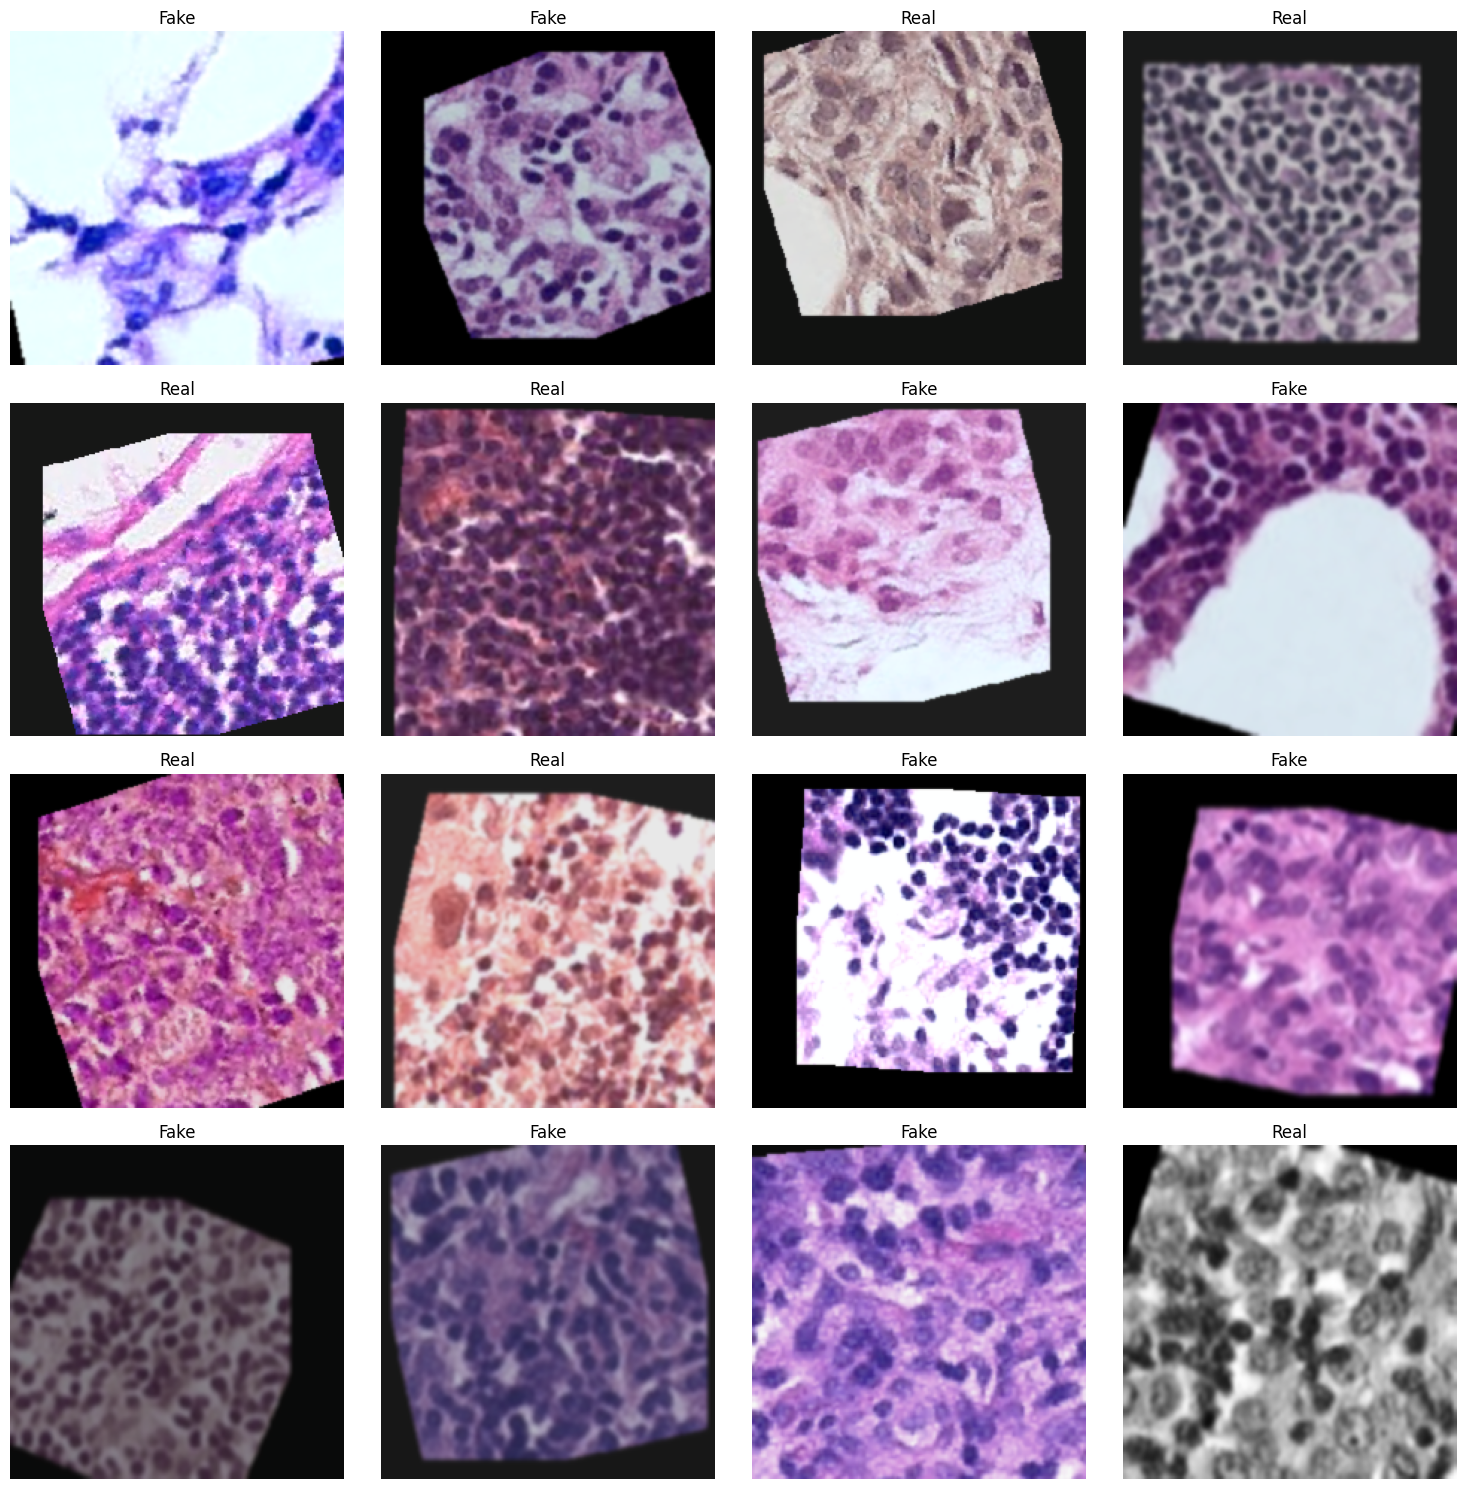

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. DEFINE THE "NUCLEAR" AUGMENTATIONS ---
heavy_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Geometry
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),

    # Color & Texture
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),

    # Tensor Setup
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 2. LOAD DATA ---
data_dir = '/content/dataset/03_Mini_Dataset/Train' # Looking at TRAIN only
if not os.path.exists(data_dir):
    print("❌ ERROR: Dataset not found. Did you run the Unzip cell?")
else:
    dataset = datasets.ImageFolder(data_dir, transform=heavy_transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    class_names = dataset.classes

    # --- 3. VISUALIZATION FUNCTION ---
    def imshow(inp, title=None):
        """Imshow for Tensor."""
        inp = inp.numpy().transpose((1, 2, 0))
        # Undo the Normalization so we can see the image normally
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)

        plt.imshow(inp)
        if title:
            plt.title(title)
        plt.axis('off')

    # Get a batch of training data
    inputs, classes = next(iter(dataloader))

    # Plot a grid of 16 images
    plt.figure(figsize=(15, 15))
    print("👀 Visualizing Heavy Augmentations (Grid of 16)...")

    # Show 4x4 Grid
    for i in range(16):
        plt.subplot(4, 4, i+1)
        imshow(inputs[i], title=class_names[classes[i]])

    plt.tight_layout()
    plt.show()

🚀 Starting Run_01_ConfigA on cuda...
📊 Dataset Stats:
   - Train Images: 8298 (Expected ~4000)
   - Val Images:   1600   (Expected ~800)
ℹ️ Class Mapping: {'Fake': 0, 'Real': 1}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 181MB/s]



Epoch 1/100
----------
Train Loss: 0.1993 Acc: 0.9168
Val Loss: 0.0175 Acc: 0.9944
   📊 Precision (Fake): 0.9975 | Recall: 0.9912 | Spec: 0.9975 | AUC: 0.9998

Epoch 2/100
----------
Train Loss: 0.0883 Acc: 0.9690
Val Loss: 0.0571 Acc: 0.9838
   📊 Precision (Fake): 1.0000 | Recall: 0.9675 | Spec: 1.0000 | AUC: 0.9979

Epoch 3/100
----------
Train Loss: 0.0715 Acc: 0.9748
Val Loss: 0.0371 Acc: 0.9863
   📊 Precision (Fake): 0.9987 | Recall: 0.9738 | Spec: 0.9988 | AUC: 0.9992

Epoch 4/100
----------
Train Loss: 0.0476 Acc: 0.9829
Val Loss: 0.0100 Acc: 0.9950
   📊 Precision (Fake): 0.9987 | Recall: 0.9912 | Spec: 0.9988 | AUC: 1.0000

Epoch 5/100
----------
Train Loss: 0.0420 Acc: 0.9870
Val Loss: 0.0074 Acc: 0.9962
   📊 Precision (Fake): 0.9987 | Recall: 0.9938 | Spec: 0.9988 | AUC: 1.0000

Epoch 6/100
----------
Train Loss: 0.0597 Acc: 0.9790
Val Loss: 0.0047 Acc: 0.9988
   📊 Precision (Fake): 1.0000 | Recall: 0.9975 | Spec: 1.0000 | AUC: 1.0000

Epoch 7/100
----------
Train Loss: 0.04

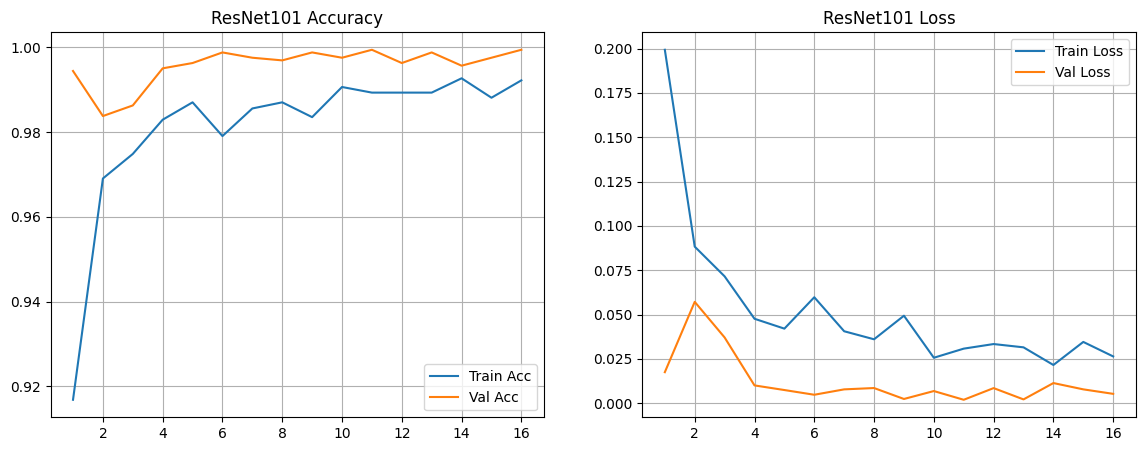

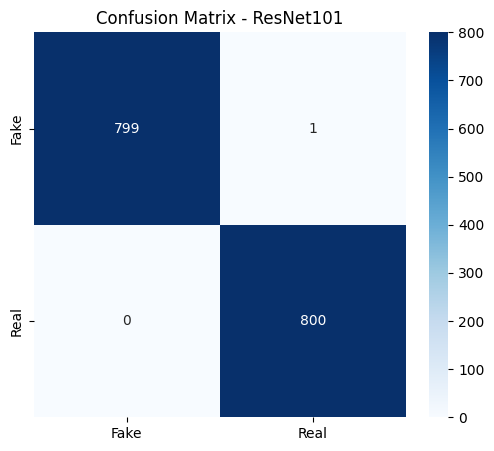

✅ Run Complete.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
RUN_NAME       = "Run_01_ConfigA"
MODEL_ARCH     = "ResNet101"
BATCH_SIZE     = 16
LEARNING_RATE  = 0.0001
OPTIMIZER_NAME = "Adam"
NUM_EPOCHS     = 100
PATIENCE       = 5

SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {RUN_NAME} on {device}...")

# --- NEW: "NUCLEAR" AUGMENTATIONS ---
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),

        # 1. GEOMETRY (Harder)
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30), # Increased from 15
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)), # Zoom/Shift

        # 2. COLOR (The Pink Killer)
        # Doubled strength to force model to ignore color bias
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1), # 10% chance to remove color entirely

        # 3. TEXTURE (The Smoothness Killer)
        # Blurs the image slightly to hide pixel-perfect artifacts
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),

        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

# --- DATASET SIZE CHECK ---
if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats:")
    print(f"   - Train Images: {dataset_sizes['Train']} (Expected ~4000)")
    print(f"   - Val Images:   {dataset_sizes['Val']}   (Expected ~800)")
else:
    print("❌ ERROR: Dataset not found! Did you unzip?")
    exit()

# Class Mapping
class_names = image_datasets['Train'].classes
print(f"ℹ️ Class Mapping: {image_datasets['Train'].class_to_idx}")

model = models.resnet101(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

if OPTIMIZER_NAME == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
best_epoch = 0
early_stop_counter = 0

history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                fake_probs = probs[:, 0]
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(fake_probs.cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision (Fake): {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_epoch = epoch
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}")
        break

time_elapsed = time.time() - since
print(f'\n✅ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'   Best Val Acc: {best_acc:.4f}')

# --- 4. SAVE RESULTS & PLOTS ---
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))

df = pd.DataFrame(history)
df.to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(df['Epoch'], df['Train_Acc'], label='Train Acc')
plt.plot(df['Epoch'], df['Val_Acc'], label='Val Acc')
plt.title(f'{MODEL_ARCH} Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(df['Epoch'], df['Train_Loss'], label='Train Loss')
plt.plot(df['Epoch'], df['Val_Loss'], label='Val Loss')
plt.title(f'{MODEL_ARCH} Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_learning_curve.png"))
plt.show()

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ Run Complete.")

📂 Saving results to: /content/drive/MyDrive/FYP_Project/Models/ResNet101/Run_02_ConfigB_Batch32
🚀 Starting ResNet101 - Run_02_ConfigB_Batch32 on cuda...
📊 Dataset Stats: Train=8298, Val=1600
⏳ Loading ResNet101 weights...
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:02<00:00, 78.8MB/s]



Epoch 1/50
----------
Train Loss: 0.1645 Acc: 0.9322
Val Loss: 0.0132 Acc: 0.9975
   📊 Precision: 0.9987 | Recall: 0.9962 | Spec: 0.9988 | AUC: 0.9999

Epoch 2/50
----------
Train Loss: 0.0542 Acc: 0.9822
Val Loss: 0.0100 Acc: 0.9956
   📊 Precision: 0.9987 | Recall: 0.9925 | Spec: 0.9988 | AUC: 1.0000

Epoch 3/50
----------
Train Loss: 0.0430 Acc: 0.9863
Val Loss: 0.0053 Acc: 0.9981
   📊 Precision: 1.0000 | Recall: 0.9962 | Spec: 1.0000 | AUC: 1.0000

Epoch 4/50
----------
Train Loss: 0.0223 Acc: 0.9931
Val Loss: 0.0055 Acc: 0.9981
   📊 Precision: 0.9975 | Recall: 0.9988 | Spec: 0.9975 | AUC: 1.0000

Epoch 5/50
----------
Train Loss: 0.0275 Acc: 0.9908
Val Loss: 0.0015 Acc: 0.9994
   📊 Precision: 0.9988 | Recall: 1.0000 | Spec: 0.9988 | AUC: 1.0000

Epoch 6/50
----------
Train Loss: 0.0147 Acc: 0.9948
Val Loss: 0.0035 Acc: 0.9988
   📊 Precision: 0.9988 | Recall: 0.9988 | Spec: 0.9988 | AUC: 1.0000

Epoch 7/50
----------
Train Loss: 0.0172 Acc: 0.9946
Val Loss: 0.0032 Acc: 0.9981
   📊 

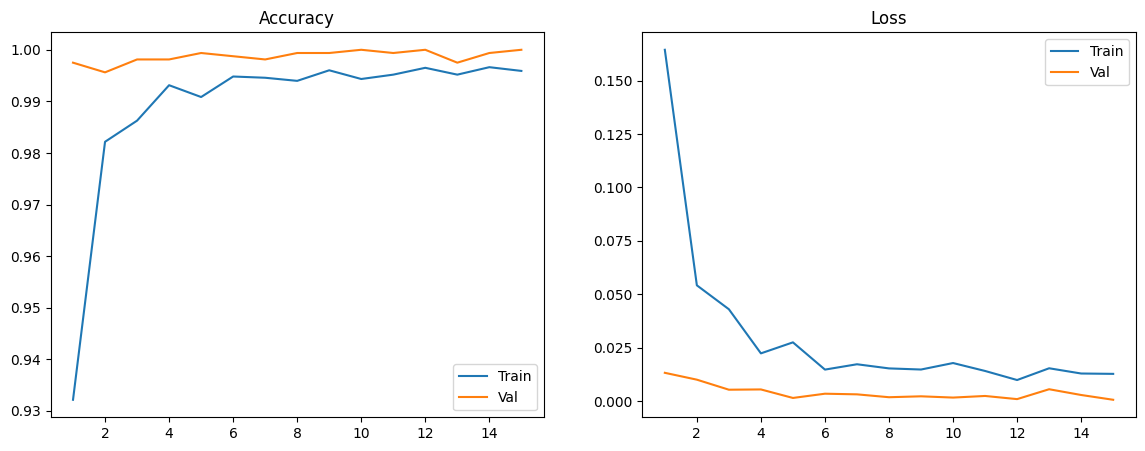

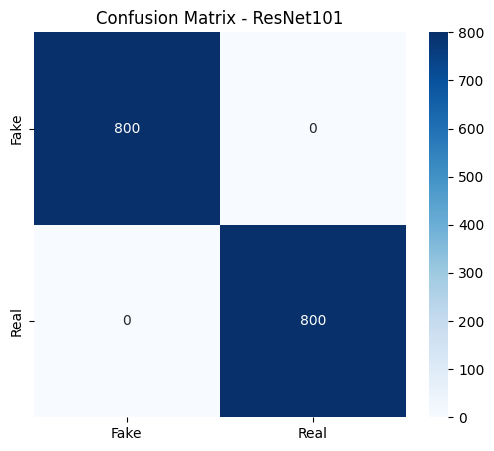

✅ Config B (Batch 32) - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (CONFIG B - BATCH 32) ---
RUN_NAME       = "Run_02_ConfigB_Batch32"  # <--- CONFIG B
MODEL_ARCH     = "ResNet101"
BATCH_SIZE     = 32                        # <--- CHANGED (Was 16)
LEARNING_RATE  = 0.0001                   
OPTIMIZER_NAME = "Adam"                    
NUM_EPOCHS     = 50
PATIENCE       = 5

# Organized Saving
SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}/{RUN_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving results to: {SAVE_DIR}")

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE SAME "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD MODEL ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.resnet101(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

if OPTIMIZER_NAME == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ Config B (Batch 32) - Done.")

📂 Saving results to: /content/drive/MyDrive/FYP_Project/Models/ResNet101/Run_03_ConfigC_SGD
🚀 Starting ResNet101 - Run_03_ConfigC_SGD on cuda...
📊 Dataset Stats: Train=8298, Val=1600
⏳ Loading ResNet101 weights...
⚙️ Using SGD Optimizer (Momentum=0.9)

Epoch 1/50
----------
Train Loss: 0.2831 Acc: 0.8819
Val Loss: 0.1176 Acc: 0.9650
   📊 Precision: 0.9346 | Recall: 1.0000 | Spec: 0.9300 | AUC: 0.9998

Epoch 2/50
----------
Train Loss: 0.1059 Acc: 0.9608
Val Loss: 0.0189 Acc: 0.9969
   📊 Precision: 0.9950 | Recall: 0.9988 | Spec: 0.9950 | AUC: 1.0000

Epoch 3/50
----------
Train Loss: 0.0810 Acc: 0.9723
Val Loss: 0.0097 Acc: 0.9988
   📊 Precision: 0.9975 | Recall: 1.0000 | Spec: 0.9975 | AUC: 1.0000

Epoch 4/50
----------
Train Loss: 0.0630 Acc: 0.9757
Val Loss: 0.0104 Acc: 0.9950
   📊 Precision: 0.9987 | Recall: 0.9912 | Spec: 0.9988 | AUC: 1.0000

Epoch 5/50
----------
Train Loss: 0.0569 Acc: 0.9806
Val Loss: 0.0106 Acc: 0.9969
   📊 Precision: 0.9975 | Recall: 0.9962 | Spec: 0.9975 | 

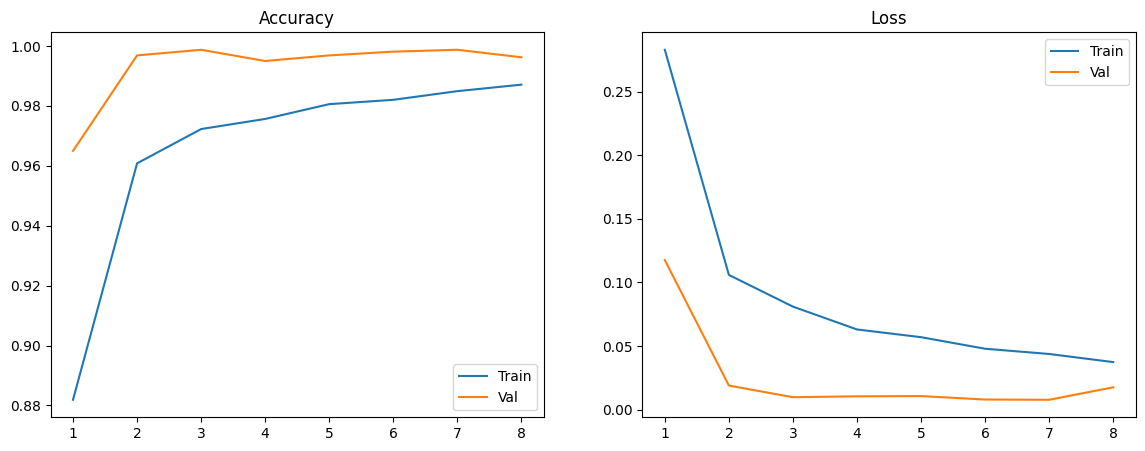

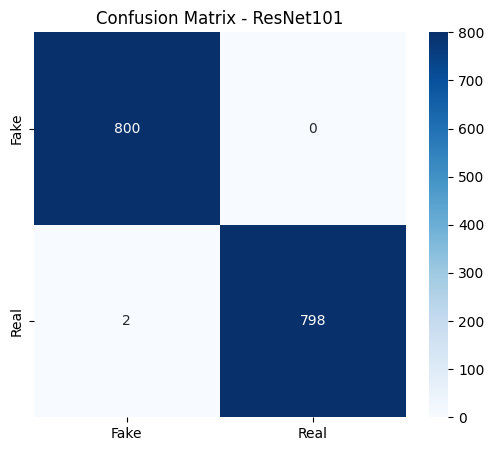

✅ Config C (SGD) - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (CONFIG C - SGD) ---
RUN_NAME       = "Run_03_ConfigC_SGD"      # <--- CONFIG C
MODEL_ARCH     = "ResNet101"
BATCH_SIZE     = 16                        # Back to 16 (Baseline)
LEARNING_RATE  = 0.001                     # <--- SGD needs 0.001 (vs 0.0001 for Adam)
OPTIMIZER_NAME = "SGD"                     # <--- SWITCHING TO SGD
NUM_EPOCHS     = 50
PATIENCE       = 5

# Organized Saving
SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}/{RUN_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving results to: {SAVE_DIR}")

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE SAME "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD MODEL ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.resnet101(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

# --- HYPERPARAMETER SWITCH ---
if OPTIMIZER_NAME == "Adam":
    print("⚙️ Using Adam Optimizer")
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    print("⚙️ Using SGD Optimizer (Momentum=0.9)")
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ Config C (SGD) - Done.")

📂 Saving results to: /content/drive/MyDrive/FYP_Project/Models/ResNet101/Run_04_ConfigD_LR_Low
🚀 Starting ResNet101 - Run_04_ConfigD_LR_Low on cuda...
📊 Dataset Stats: Train=8298, Val=1600
⏳ Loading ResNet101 weights...
⚙️ Using Adam Optimizer (LR=1e-05)

Epoch 1/50
----------
Train Loss: 0.4681 Acc: 0.7990
Val Loss: 0.1206 Acc: 0.9825
   📊 Precision: 0.9898 | Recall: 0.9750 | Spec: 0.9900 | AUC: 0.9978

Epoch 2/50
----------
Train Loss: 0.1517 Acc: 0.9458
Val Loss: 0.0462 Acc: 0.9931
   📊 Precision: 0.9925 | Recall: 0.9938 | Spec: 0.9925 | AUC: 0.9995

Epoch 3/50
----------
Train Loss: 0.1022 Acc: 0.9630
Val Loss: 0.0310 Acc: 0.9944
   📊 Precision: 0.9962 | Recall: 0.9925 | Spec: 0.9962 | AUC: 0.9996

Epoch 4/50
----------
Train Loss: 0.0783 Acc: 0.9741
Val Loss: 0.0183 Acc: 0.9956
   📊 Precision: 0.9987 | Recall: 0.9925 | Spec: 0.9988 | AUC: 0.9998

Epoch 5/50
----------
Train Loss: 0.0686 Acc: 0.9776
Val Loss: 0.0203 Acc: 0.9919
   📊 Precision: 0.9987 | Recall: 0.9850 | Spec: 0.9988

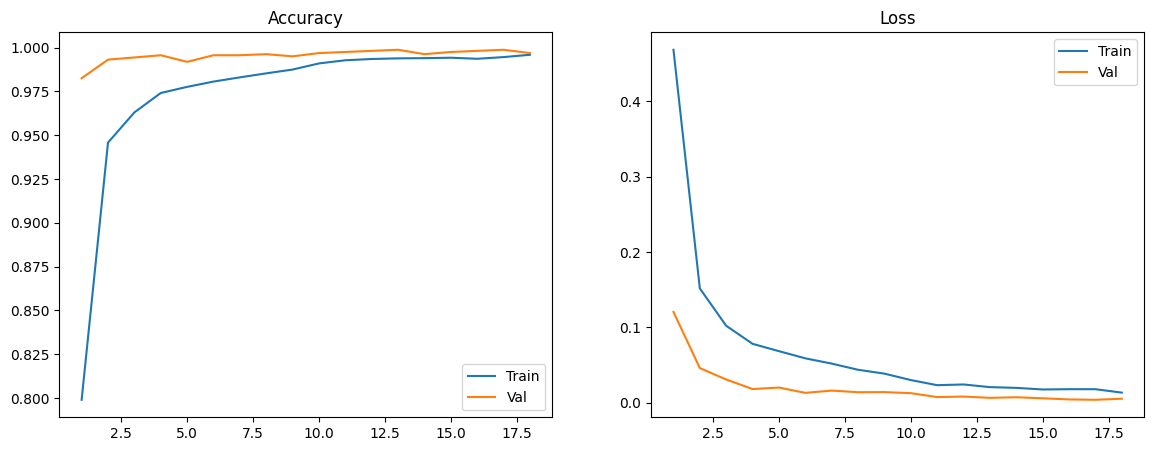

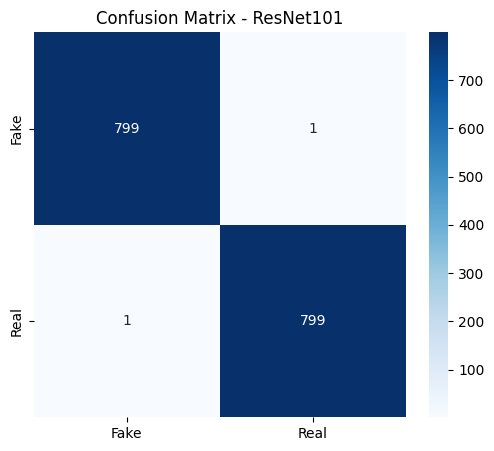

✅ Config D (Low LR) - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (CONFIG D - LOW LR) ---
RUN_NAME       = "Run_04_ConfigD_LR_Low"   # <--- CONFIG D
MODEL_ARCH     = "ResNet101"
BATCH_SIZE     = 16                        # Baseline
LEARNING_RATE  = 0.00001                   # <--- CHANGED: 1e-5 (Very Small)
OPTIMIZER_NAME = "Adam"                    # Baseline
NUM_EPOCHS     = 50
PATIENCE       = 5

# Organized Saving
SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}/{RUN_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving results to: {SAVE_DIR}")

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE SAME "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD MODEL ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.resnet101(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

if OPTIMIZER_NAME == "Adam":
    print(f"⚙️ Using Adam Optimizer (LR={LEARNING_RATE})")
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ Config D (Low LR) - Done.")